<a href="https://colab.research.google.com/github/tejalkv0/LangGraph-and-LLM/blob/main/Chain_of_thought%2BThree_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from transformers import pipeline

MODELS = {
    "model_1": "Qwen/Qwen2.5-1.5B-Instruct",
    "model_2": "HuggingFaceTB/SmolLM2-1.7B-Instruct",
    "model_3": "Qwen/Qwen2.5-0.5B-Instruct",
}

SIMULATE_FAILURE = {"model_1": False, "model_2": False, "model_3": False}  # True = fake network error
SKIP = set()   # models to bypass entirely, e.g. {"model_2"}

_loaded = {}   # models load lazily, only when a node needs them

def call_model(key: str, prompt: str) -> str:
    if SIMULATE_FAILURE[key]:
        raise ConnectionError(f"Simulated network failure for {key}")
    if key not in _loaded:   # a real download/network error here also triggers fallback
        _loaded[key] = pipeline("text-generation", model=MODELS[key], device_map="auto")
    messages = [{"role": "user", "content": prompt}]
    out = _loaded[key](messages, max_new_tokens=120, do_sample=False)
    return out[0]["generated_text"][-1]["content"].strip()

## 3. Build the graph

In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    prompt: str
    answer: str
    used_model: str
    tried: List[str]
    errors: List[str]

ORDER = ["model_1", "model_2", "model_3"]

def make_node(key: str):
    def node(state: State):
        tried = state["tried"] + [key]
        try:
            return {"answer": call_model(key, state["prompt"]), "used_model": key, "tried": tried}
        except Exception as e:
            return {"errors": state["errors"] + [f"{key} failed: {e}"], "tried": tried}
    return node

# Done if we have an answer; otherwise go to the next model that
# hasn't been tried and isn't skipped; if none are left, stop.
def route(state: State):
    if state["answer"]:
        return END
    for m in ORDER:
        if m not in state["tried"] and m not in SKIP:
            return m
    return END

targets = {"model_1": "model_1", "model_2": "model_2", "model_3": "model_3", END: END}

graph = StateGraph(State)
for m in ORDER:
    graph.add_node(m, make_node(m))

graph.add_conditional_edges(START, route, targets)
for m in ORDER:
    graph.add_conditional_edges(m, route, targets)

app = graph.compile()

## 4. Test every scenario
Expected paths:
- `model_1`
- `model_1 -> model_2`
- `model_1 -> model_2 -> model_3`
- `model_1 -> model_3`

In [ ]:
def run(title, fail=(), skip=()):
    for k in SIMULATE_FAILURE:
        SIMULATE_FAILURE[k] = k in fail
    SKIP.clear(); SKIP.update(skip)

    r = app.invoke({
        "prompt": "Explain in 2 sentences why the sky is blue.",
        "answer": "", "used_model": "", "tried": [], "errors": [],
    })
    print(f"=== {title} ===")
    print("Path    :", " -> ".join(r["tried"]))
    print("Answered:", r["used_model"] or "nobody (all failed)")
    print("Answer  :", r["answer"][:200], "\n")

run("1 works",                          fail=[])
run("1 fails -> 2 answers",             fail=["model_1"])
run("1 and 2 fail -> 3 answers",        fail=["model_1", "model_2"])
run("1 fails, 2 skipped -> 3 answers",  fail=["model_1"], skip=["model_2"])

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== 1 and 2 fail -> 3 answers ===
Path    : model_1 -> model_2 -> model_3
Answered: model_3
Answer  : The sky appears blue because it reflects sunlight and scatters other colors of light. The Earth's atmosphere, which contains nitrogen and oxygen, also plays a role in this phenomenon. Nitrogen gas abs 

=== 1 fails, 2 skipped -> 3 answers ===
Path    : model_1 -> model_3
Answered: model_3
Answer  : The sky appears blue because it reflects sunlight and scatters other colors of light. The Earth's atmosphere, which contains nitrogen and oxygen, also plays a role in this phenomenon. Nitrogen gas abs 



## Optional: visualize the graph

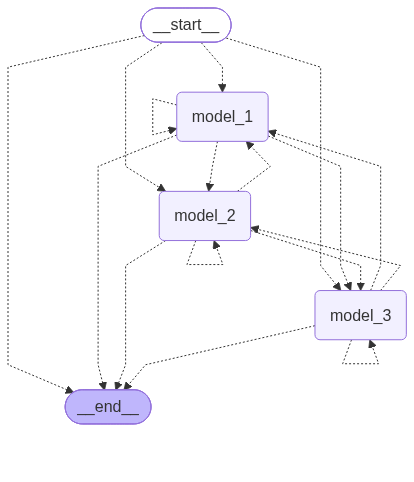

In [ ]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())